# Flood Detection using Geospatial Foundation Models  

### Objective
This notebook implements an end-to-end flood detection workflow for India dataset using the IBM Prithvi geospatial foundation model, fine-tuned for semantic segmentation on multi-sensor Earth observation data.

The approach combines complementary satellite observations to improve flood detection reliability:

- EOS-4 SAR backscatter for flood sensitivity under cloud cover and adverse weather  
- Resourcesat-2 / 2A optical multispectral imagery for enhanced land–water discrimination  
 

### References
- IBM Geospatial Flood Detection : 
  https://github.com/ibm-granite/geospatial/tree/main/uki-flooddetection  

- IBM–NASA Prithvi Foundation Models for Earth Observation:  
  https://huggingface.co/collections/ibm-nasa-geospatial/prithvi-for-earth-observation


# Setup
Install terratoch - https://github.com/terrastackai/terratorch

Works well with python 3.11

In [1]:
!python --version

Python 3.12.12


In [4]:
!pip install -q condacolab
import condacolab
condacolab.install()


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
!conda create --name myenv python=3.11

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/myenv

  added / updated specs:
    - python=3.11


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bzip2-1.0.8                |       hda65f42_8         254 KB  conda-forge
    ca-certificates-2026.1.4   |       hbd8a1cb_0         143 KB  conda-forge
    icu-78.2                   |       h33c6efd_0        12.1 MB  conda-forge
    ld_impl_linux-64-2.45      |default_hbd61a6d_105         714 KB  conda-forge
    libexpat-2.7.3             |       hecca717_0          75 KB  conda-forge
    libffi-3.5.2               |       h3435931_0          57 KB  conda-forge
    libgcc

In [2]:
!source activate myenv && python --version

Python 3.11.14


In [8]:
!conda install -c conda-forge terratorch

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - terratorch


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _python_abi3_support-1.0   |       hd8ed1ab_2           8 KB  conda-forge
    absl-py-2.4.0              |     pyhd8ed1ab_0         107 KB  conda-forge
    adwaita-icon-theme-49.0    |           unix_0         617 KB  conda-forge
    aenum-3.1.16               |     pyhcf101f3_0         108 KB  conda-forge
    affine-2.4.0               |     pyhd8ed1ab_1          19 KB  conda-forge
    aiohappyeyeballs-2.6.1     |     pyhd8ed1ab_0          19 KB  conda-forge
    aiohttp-3.13.3             |  py311h55b9665_0        1001 KB  conda-forge
    aiosignal-1.4.0            |     pyhd8ed1ab_0          13 KB  conda-forge
    albucore-0.0.16            |     pyhd8ed1ab_0          15

In [9]:
# # !pip install git+https://github.com/IBM/terratorch.git
# !pip install terratorch

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
import sys 
import os
import sys
import numpy as np
import torch

import terratorch
from terratorch.datamodules import MultiTemporalCropClassificationDataModule
from terratorch.tasks import SemanticSegmentationTask
from terratorch.datasets.transforms import FlattenTemporalIntoChannels, UnflattenTemporalFromChannels

import albumentations
from albumentations.pytorch import ToTensorV2

import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint
import rasterio

## Flood Dataset

**Satellite Data:** ISRO EOS-4 SAR and Resourcesat-2/2A optical imagery.  

- **EOS-4 SAR:** HH and HV polarizations  
- **Resourcesat-2/2A:** Green, Red, NIR, and SWIR bands  

**Inland Water Bodies:** Global Surface Water Explorer  
https://global-surface-water.appspot.com/#data  

**Flood Inundation Maps (India):** West Bengal, May 29, 2024, from the Bhuvan platform - https://bhuvan-app1.nrsc.gov.in/nfvas/

**Label Creation:** Flood labels are generated using a combination of water bodies and the flood inundation maps.  

**Temporal Alignment:** Data is preferably collected for the same locations and dates. A temporal mismatch of ±1 day is allowed if necessary.  

**Spatial Resolution:** 18 m, with 512×512 patches containing the following channels: Label, HH, HV, Band1 (Green), Band2 (Red), Band3 (NIR), Band4 (SWIR).  

This section introduces the dataset and prepares it for further analysis.


In [14]:
dataset_path = '/kaggle/input/ibm-flood-data/data/'

In [15]:
datamodule = terratorch.datamodules.GenericNonGeoSegmentationDataModule(
    batch_size=4,
    num_workers=2,
    num_classes=2,

    # Define dataset paths
    train_data_root=dataset_path+'image',
    train_label_data_root=dataset_path+'label',
    val_data_root=dataset_path+'image',
    val_label_data_root=dataset_path+'label',
    test_data_root=dataset_path+'image',
    test_label_data_root=dataset_path+'label',

    # Define splits
    train_split=dataset_path+'split/train.txt',
    val_split=dataset_path+'split/val.txt',
    test_split=dataset_path+'split/test.txt',

    img_grep='*image.tif',
    label_grep='*label.tif',

    train_transform=[
        albumentations.D4(), # Random flips and rotation
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,  # Using ToTensor() by default
    test_transform=None,
    
    # mean and stds of HH, HV, Band1 (Green), Band2 (Red), Band3 (NIR), Band4 (SWIR)
    means = [841.1257, 371.6175, 1734.1789, 1588.3142, 1742.8452, 1218.5551],
    stds = [473.7090, 170.3611, 623.0474, 612.8465, 564.5835, 528.0894],
    no_data_replace=0,
    no_label_replace=-1,
    # We use all six bands of the data, so we don't need to define dataset_bands and output_bands.
    predict_data_root = "/kaggle/input/ibm-flood-data/data/prediction/image"
)

# Setup train and val datasets
datamodule.setup("fit")

In [16]:
# checking datasets train split size
train_dataset = datamodule.train_dataset
print(len(train_dataset))

# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)



59


10

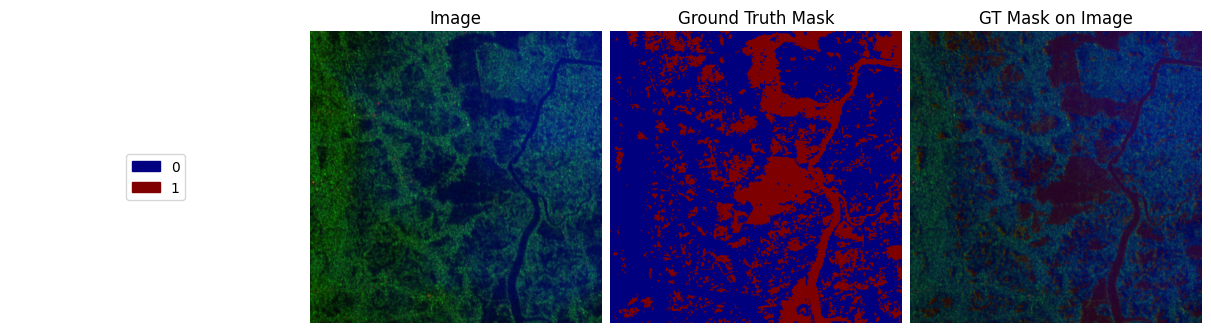

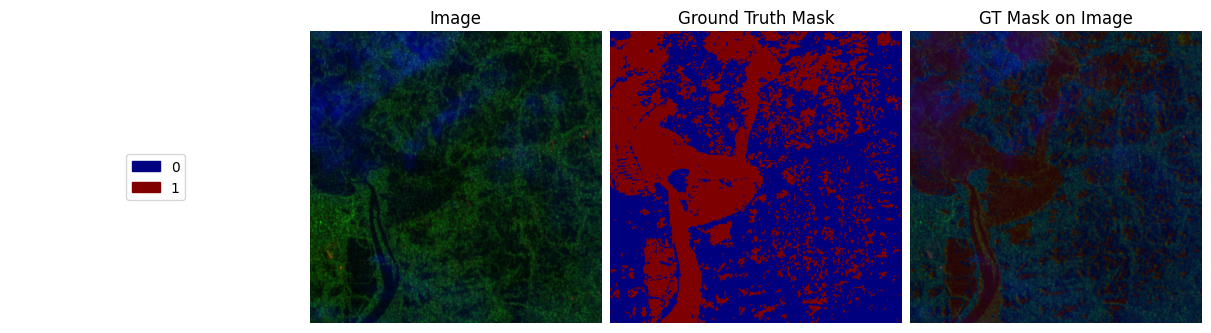

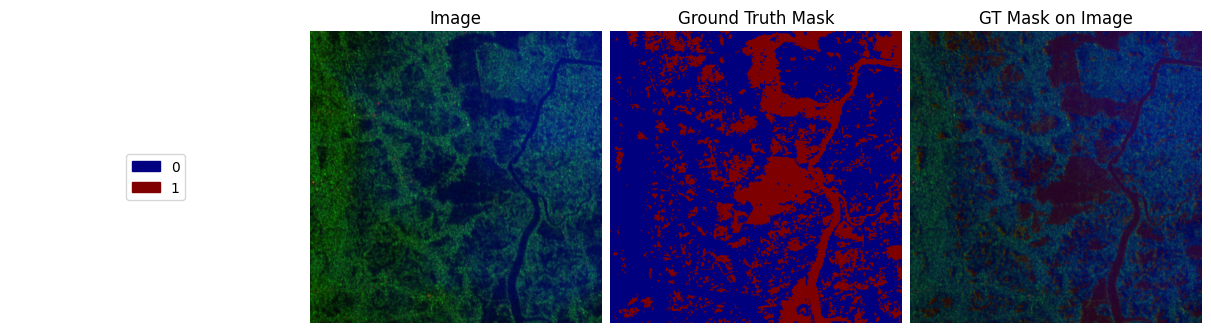

In [17]:
# plotting a few samples
val_dataset.plot(val_dataset[0])
val_dataset.plot(val_dataset[1])

## Fine-tuning the IBM Prithvi Model

In this section, we fine-tune the IBM Prithvi geospatial foundation model for flood detection over India. The model, pretrained on global Earth observation data, is adapted to multi-sensor inputs including SAR and optical imagery, and trained to segment flooded areas accurately.

The fine-tuning process leverages high-resolution patches and flood labels derived from Bhuvan inundation maps and water body datasets. During training, the model learns India-specific flood patterns, improving its ability to identify inundated regions under diverse land cover and weather conditions.

Monitoring and checkpointing ensure the best-performing model is saved based on validation metrics.


In [18]:
#Hyperparameters
EPOCHS = 1 # Set number of epochs; 1 for testing
BATCH_SIZE = 16 
LR = 2.0e-5
WEIGHT_DECAY = 0.1
HEAD_DROPOUT=0.1
FREEZE_BACKBONE = False

BANDS =[1,2,3,4,5,6]
NUM_FRAMES = 1
CLASS_WEIGHTS =[0.26,0.74]
SEED = 0
OUT_DIR='/kaggle/working/'


In [19]:
SEED = 0

pl.seed_everything(SEED)

# Logger
logger = TensorBoardLogger(
    save_dir=OUT_DIR,
    name="test",
)

# Callbacks
checkpoint_callback = ModelCheckpoint(
    monitor="val/mIoU",
    mode="max",
    dirpath=os.path.join(OUT_DIR, "test", "checkpoints"),
    filename="best-checkpoint-{epoch:02d}-{val_loss:.2f}",
    save_top_k=1,
)

# Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices="auto",
    precision="bf16-mixed",
    num_nodes=1,
    logger=logger,
    max_epochs=EPOCHS,
    check_val_every_n_epoch=1,
    log_every_n_steps=10,
    enable_checkpointing=True,
    callbacks=[checkpoint_callback],
    # limit_predict_batches=1,  # predict only in the first batch for generating plots
)

# DataModule
data_module = datamodule


# Model

decoder_args = dict(
    decoder="UperNetDecoder",
    decoder_channels=256,
    decoder_scale_modules=True,
)

necks = [
    #dict(
    #        name="SelectIndices",
    #        # indices=[2, 5, 8, 11]    # indices for prithvi_vit_100
    #       #indices=[5, 11, 17, 23],   # indices for prithvi_eo_v2_300
    #        # indices=[7, 15, 23, 31]  # indices for prithvi_eo_v2_600
    #    ),
    dict(
            name="ReshapeTokensToImage",
            effective_time_dim=NUM_FRAMES,
        )
    ]

backbone_args = dict(
    backbone_pretrained=True,
    backbone="prithvi_eo_v2_300_tl", # other models are availble like prithvi_eo_v2_300, prithvi_eo_v2_tiny_tl, prithvi_eo_v2_600, prithvi_eo_v2_600_tl
    #backbone_coords_encoding=["time", "location"],
    backbone_bands=BANDS,
    backbone_num_frames=1, # 1 is the default value,    
    # backbone_pretrained_cfg_overlay=None
    )

model_args = dict(
    **backbone_args,
    **decoder_args,
    num_classes=2,
    head_dropout=HEAD_DROPOUT,
    necks=necks,
    rescale=True,
)
    

model = SemanticSegmentationTask(
    model_args=model_args,
    plot_on_val=False,
    class_weights=CLASS_WEIGHTS,
    loss="ce",
    lr=LR,
    optimizer="AdamW",
    optimizer_hparams=dict(weight_decay=WEIGHT_DECAY),
    ignore_index=-1,
    freeze_backbone=FREEZE_BACKBONE,
    freeze_decoder=False,
    model_factory="EncoderDecoderFactory",
)



INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Prithvi_EO_V2_300M_TL.pt:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

In [20]:
trainer.fit(model, datamodule=data_module)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  318 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 318 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 651                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


## Testing

This section evaluates the fine-tuned Prithvi model on unseen flood events. 

In [21]:
!ls /kaggle/working/test/checkpoints/

'best-checkpoint-epoch=00-val_loss=0.00.ckpt'


In [23]:
datamodule.setup("test")
#sample checkpoint from 37th epoch for testing..
best_ckpt_path = "/kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt"

In [24]:
test_results = trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

INFO: Restoring states from the checkpoint path at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │     0.810320258140564     │
│    test/Boundary_mIoU     │    0.07755181938409805    │
│   test/Class_Accuracy_0   │    0.7070078253746033     │
│   test/Class_Accuracy_1   │    0.9136326313018799     │
│       test/F1_Score       │    0.7805790901184082     │
│        test/IoU_0         │    0.6730487942695618     │
│        test/IoU_1         │    0.6084678173065186     │
│    test/Pixel_Accuracy    │    0.7832038998603821     │
│         test/loss         │    0.43272846937179565    │
│         test/mIoU         │    0.6407582759857178     │
│      test/mIoU_Micro      │    0.6436607241630554     │
└───────────────────────────┴───────────────────────────┘

## Prediction

This section runs inference using the fine-tuned model and generates flood predictions for unseen data. The predicted flood masks are saved as georeferenced GeoTIFF files, preserving the spatial metadata of the input imagery for downstream analysis and visualization.


In [26]:
datamodule.setup("predict")

predictions = trainer.predict(
    model,
    datamodule=datamodule,
    ckpt_path=best_ckpt_path
)

output_dir = "/kaggle/working/prediction"
os.makedirs(output_dir, exist_ok=True)

for batch_idx, (preds, file_paths) in enumerate(predictions):
    
    if isinstance(preds, tuple):
        preds = preds[0]

    if preds.ndim == 4:               # [B, C, H, W]
        preds = preds.argmax(dim=1)   # [B, H, W]

    preds = preds.cpu().numpy().astype("int16")

    for i in range(preds.shape[0]):
        arr = preds[i]
        arr[arr < 0] = -1             # 🔒 enforce ignore_index

        ref_path = file_paths[i]
        with rasterio.open(ref_path) as src:
            meta = src.meta.copy()

        meta.update({
            "count": 1,
            "dtype": "int16",
            "nodata": -1,
            "compress": "lzw",
        })

        out_name = (
            os.path.splitext(os.path.basename(ref_path))[0]
            + ".tif"
        )
        out_path = os.path.join(output_dir, out_name)

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(arr, 1)

        print(f"Saved {out_path}")


INFO: Restoring states from the checkpoint path at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /kaggle/working/test/checkpoints/best-checkpoint-epoch=00-val_loss=0.00.ckpt


Output()

Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_080_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_081_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_082_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_083_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_084_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_085_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_086_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_087_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_088_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_089_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_090_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_091_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_092_image.tif
Saved /kaggle/working/prediction/20240529_EO4_RES2_fl_pid_093_im

# Convert prediction tif files to Kaggle-style run-length encoding (RLE) Submission csv

In [28]:
import numpy as np

def mask_to_rle(mask):
    """
    Convert binary mask to RLE (Kaggle format).
    Mask must be 2D numpy array with values 0 or 1.
    """
    pixels = mask.flatten(order="F")  # column-major
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)


In [38]:
import rasterio
import pandas as pd
from pathlib import Path

tif_dir = Path("/kaggle/working/prediction")   # folder with .tif files
output_csv = "/kaggle/working/prediction/submission.csv"

rows = []

for tif_path in sorted(tif_dir.glob("*.tif")):
    with rasterio.open(tif_path) as src:
        mask = src.read(1)

    # Convert to binary
    mask = (mask > 0).astype(np.uint8)

    rle = mask_to_rle(mask)

    rows.append({
        "id": tif_path.name.replace("_image.tif", ""), 
        "rle_mask": rle
    })

df = pd.DataFrame(rows)
df = df.replace("", 0).fillna(0) #replace null/ na with zero - kaggle compatible
df.to_csv(output_csv, index=False)
print(f"Saved Kaggle RLE CSV : {output_csv}")


Saved Kaggle RLE CSV : /kaggle/working/prediction/submission.csv
